In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as cp
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from FallbackGen import FallbackGen
from TDECalculator import TDECalculator
import gc

plt.style.use("plot_style.mplstyle")
plt.rc('text', usetex=True)

In [2]:
import sys

def show_large_vars(min_mb=10):
    for name, obj in list(globals().items()):
        size = sys.getsizeof(obj) / 1e6
        if size > min_mb:
            print(f"{name}: {size:.1f} MB")

In [3]:
MBH = 1e6
Rp = 7.5
a = -0.99
N = 1000
E = 1.0
Q = 0.0
orbit="rel"

mass2_p = TDECalculator('MAMS1Msun', orbit, MBH, Rp, -a, N=N)
mass2_r = TDECalculator('MAMS1Msun', orbit, MBH, Rp, a, N=N)
mass2_s = TDECalculator('MAMS1Msun', orbit, MBH, Rp, 0.0, N=N)

In [4]:
import psutil, os

def mem(label):
    process = psutil.Process(os.getpid())
    print(f"{label}: {process.memory_info().rss / 1e9:.2f} GB")

In [5]:
sample_p = mass2_p.rel_whole_star_sample()

In [6]:
radii_p = sample_p['rr']

rtde = mass2_p.R_TDE
Lz = mass2_p.mom_kerr_analytic(Rp, a)
E = 1.0
Q = 0

radii = np.where(
    radii_p <= 0.5,
    rtde - radii_p * mass2_p.Rstar,
    rtde + radii_p * mass2_p.Rstar
)

deltaE = mass2_p.Rstar / mass2_p.Rp**2 

i = int(np.random.uniform(0, 1132))
j = int(np.random.uniform(0, 90000))
dE = sample_p['dEnergy_random'] * deltaE 
dLz = mass2_p.dLz_random
dQ = mass2_p.dQ_random
mass_ratio = mass2_p.mass_ratio

In [7]:
dT_p = FallbackGen(mass_ratio, a, radii, Rp, E, Lz, Q, dE, dLz, dQ, N)
np.save('dT_p.npy', dT_p.dTs)
del dT_p
gc.collect() 
show_large_vars() 

Computing radial periods for 101,880,000 particles ...
  E  range: [0.997154, 1.002846]
  Q  range: [-2.808e+02, 2.808e+02]
  chunk_size = 500,000
  Finding roots (batched eigensolver) ...
  Bound: 51,038,766 / 101,880,000
  Valid roots: 4,482,317
  Valid Lambda_r: 4,482,317
  Quadrature: 9 chunks ...
    chunk 9/9  (100%)
  Successful T_r: 4,432,881 / 101,880,000
dE: 815.0 MB
dLz: 815.0 MB
dQ: 815.0 MB


In [8]:
sample_r = mass2_r.rel_whole_star_sample()

In [9]:
radii_r = sample_r['rr']

rtde = mass2_r.R_TDE
Lz = mass2_r.mom_kerr_analytic(Rp, a)
E = 1.0
Q = 0

radii = np.where(
    radii_r <= 0.5,
    rtde - radii_r * mass2_r.Rstar,
    rtde + radii_r * mass2_r.Rstar
)

deltaE = mass2_r.Rstar / mass2_r.Rp**2 

i = int(np.random.uniform(0, 1132))
j = int(np.random.uniform(0, 90000))
dE = sample_r['dEnergy_random'] * deltaE 
dLz = mass2_r.dLz_random
dQ = mass2_r.dQ_random
mass_ratio = mass2_r.mass_ratio

In [10]:
dT_r = FallbackGen(mass_ratio, a, radii, Rp, E, Lz, Q, dE, dLz, dQ, N)
np.save('dT_r.npy', dT_r.dTs)
del dT_r
gc.collect() 
show_large_vars() 

Computing radial periods for 101,880,000 particles ...
  E  range: [0.996805, 1.003195]
  Q  range: [-3.872e+02, 3.872e+02]
  chunk_size = 500,000
  Finding roots (batched eigensolver) ...
  Bound: 50,992,624 / 101,880,000
  Valid roots: 48,831,915
  Valid Lambda_r: 48,831,915
  Quadrature: 98 chunks ...
    chunk 98/98  (100%)
  Successful T_r: 48,740,168 / 101,880,000
dE: 815.0 MB
dLz: 815.0 MB
dQ: 815.0 MB


In [11]:
sample_s = mass2_s.rel_whole_star_sample()

In [12]:
del dE, dLz, dQ

In [13]:
radii_s = sample_s['rr']

rtde = mass2_s.R_TDE
Lz = mass2_s.mom_kerr_analytic(Rp, a)
E = 1.0
Q = 0

radii = np.where(
    radii_s <= 0.5,
    rtde - radii_s * mass2_s.Rstar,
    rtde + radii_s * mass2_s.Rstar
)

deltaE = mass2_s.Rstar / mass2_s.Rp**2 

i = int(np.random.uniform(0, 1132))
j = int(np.random.uniform(0, 90000))
dE = sample_s['dEnergy_random'] * deltaE 
dLz = mass2_s.dLz_random
dQ = mass2_s.dQ_random
mass_ratio = mass2_s.mass_ratio

In [14]:
dT_s = FallbackGen(mass_ratio, a, radii, Rp, E, Lz, Q, dE, dLz, dQ, N)
np.save('dT_s.npy', dT_s.dTs)
del dT_s
gc.collect() 

Computing radial periods for 101,880,000 particles ...
  E  range: [0.996841, 1.003159]
  Q  range: [-5.469e-05, 5.469e-05]
  chunk_size = 500,000
  Finding roots (batched eigensolver) ...
  Bound: 51,177,154 / 101,880,000
  Valid roots: 47,781,369
  Valid Lambda_r: 47,781,369
  Quadrature: 96 chunks ...
    chunk 96/96  (100%)
  Successful T_r: 43,478,707 / 101,880,000


0

In [15]:
del dE, dLz, dQ

In [16]:
n_ex = TDECalculator('MAMS1Msun', Rp=Rp, a=0.0, N=N)

In [17]:
whole_star_sample4 = n_ex.whole_star_sample()

In [54]:
def make_plot_dicts(whole_star_sample, dT, delta):
    dE_rand = whole_star_sample['dEnergy_random']
    dT_rand = dT / delta
    dMass   = whole_star_sample['dMass']

    bins_E = np.linspace(-2, 2, 1000)
    bins_T = np.logspace(0, 6, 1000)

    hist_E, edges_E = np.histogram(dE_rand.flatten(), bins=bins_E,
                                   weights=dMass.flatten(), density=True)
    hist_T, edges_T = np.histogram(dT_rand.flatten(), bins=bins_T,
                                   weights=dMass.flatten(), density=True)

    return {"x": 0.5*(edges_E[:-1]+edges_E[1:]), "y": hist_E}, \
           {"x": 0.5*(edges_T[:-1]+edges_T[1:]), "y": hist_T}

In [55]:
def energy_plots(whole_star_sample): 
    # unpack
    dE_rand   = whole_star_sample['dEnergy_random']      # shape (nr-1, N_Omega)
    dE_unp    = whole_star_sample['dEnergy_unperturbed']
    dT_rand   = whole_star_sample['dT_random']
    dT_unp    = whole_star_sample['dT_unperturbed']
    dMass     = whole_star_sample['dMass']               # same shape

    # set up figure
    # fig, (axE, axT) = plt.subplots(1, 2, figsize=(12,5))

    # histograms in E
    bins_E = np.linspace(-2, 2, 200)
    # axE.hist(dE_rand.flatten(),
    #         weights=dMass.flatten(),
    #         bins=bins_E,
    #         density=True,
    #         alpha=0.5)
    # axE.set_yscale('log')
    # axE.set_xlabel(r'$ E / \Delta E$')
    # axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
    # axE.set_xlim(-1,1)
    # axE.set_ylim(1e-5)
 
    # histograms in T
    bins_T = np.logspace(0, 6, 200)
#     axT.hist(dT_rand.flatten(),
#             weights=dMass.flatten(),
#             bins=bins_T,
#             density=True,
#             alpha=0.5)
#     # overplot T^{-5/3} reference
#     axT.plot(bins_T, 10*bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
#     axT.set_xscale('log')
#     axT.set_yscale('log')
#     axT.set_xlabel(r'$T / \Delta T$')
#     axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
#     axT.set_xlim(1,2000)
#     axT.set_ylim(2e-5,0.1)

#     plt.tight_layout()
#     plt.show()
    
    hist_vals_E, bin_edges_E = np.histogram(
        dE_rand.flatten(),
        bins=bins_E,
        weights=dMass.flatten(),
        density=True
        )
    
    hist_vals_T, bin_edges_T = np.histogram(
        dT_rand.flatten(),
        bins=bins_T,
        weights=dMass.flatten(),
        density=True
        )
    
    bin_centers_E = 0.5 * (bin_edges_E[:-1] + bin_edges_E[1:]) # Save the curve for later
    bin_centers_T = 0.5 * (bin_edges_T[:-1] + bin_edges_T[1:]) # Save the curve for later
    
    curve_E = {
        "x": bin_centers_E,
        "y": hist_vals_E
        }
    
    curve_T = {
        "x": bin_centers_T,
        "y": hist_vals_T
        }
    
    return curve_E, curve_T

In [20]:
n_E, n_T = energy_plots(whole_star_sample4)

In [21]:
DeltaE = n_ex.Rstar / n_ex.Rp**2
DeltaT = 1 / DeltaE**1.5

In [22]:
dT_p = np.load('dT_p.npy')
dT_r = np.load('dT_r.npy')
dT_s = np.load('dT_s.npy')

In [56]:
rel_p_E, rel_p_T = make_plot_dicts(sample_p, dT_p, DeltaT)

In [57]:
rel_r_E, rel_r_T = make_plot_dicts(sample_r, dT_r, DeltaT)

In [58]:
rel_s_E, rel_s_T = make_plot_dicts(sample_s, dT_s, DeltaT)

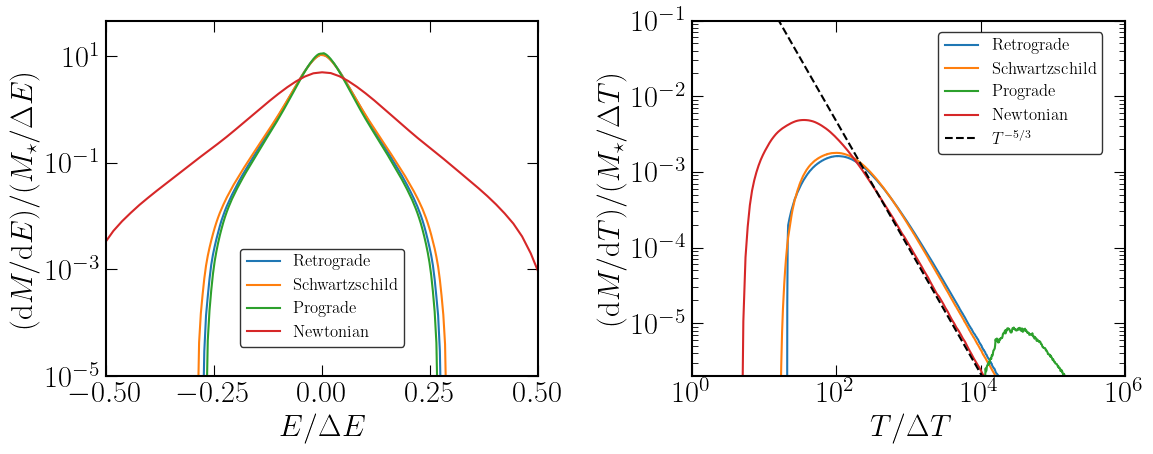

In [59]:
# Build dicts

# Plot
fig, (axE, axT) = plt.subplots(1, 2, figsize=(12, 5))

# Energy
bins_E = np.linspace(-2, 2, 200)
axE.plot(rel_r_E["x"], rel_r_E["y"], label="Retrograde")
axE.plot(rel_s_E["x"], rel_s_E["y"], label="Schwartzschild")
axE.plot(rel_p_E["x"], rel_p_E["y"], label="Prograde")
axE.plot(n_E["x"],   n_E["y"],   label="Newtonian")
axE.set_yscale('log')
axE.set_xlabel(r'$E / \Delta E$')
axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')
axE.set_xlim(-0.5,0.5)
axE.set_ylim(1e-5)

axE.legend(
    loc='center',            # the point on the legend box to anchor
    bbox_to_anchor=(0.5, 0.22),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

# Period
axT.plot(rel_r_T["x"], rel_r_T["y"], label="Retrograde")
axT.plot(rel_s_T["x"], rel_s_T["y"], label="Schwartzschild")
axT.plot(rel_p_T["x"], rel_p_T["y"], label="Prograde")
axT.plot(n_T["x"],   n_T["y"],   label="Newtonian")
bins_T = np.logspace(0, 6, 200)
axT.plot(bins_T, 10 * bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
axT.set_xscale('log')
axT.set_yscale('log')
axT.set_xlabel(r'$T / \Delta T$')
axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')
axT.set_xlim(1,1000000)
axT.set_ylim(2e-6,0.1)

axT.legend(
    loc='upper left',            # the point on the legend box to anchor
    bbox_to_anchor=(0.55, 0.99),  
    frameon=True,                  # draw the box
    edgecolor='black',             # box outline color
    facecolor='white',             
    fontsize=12
)

plt.tight_layout()
plt.show()

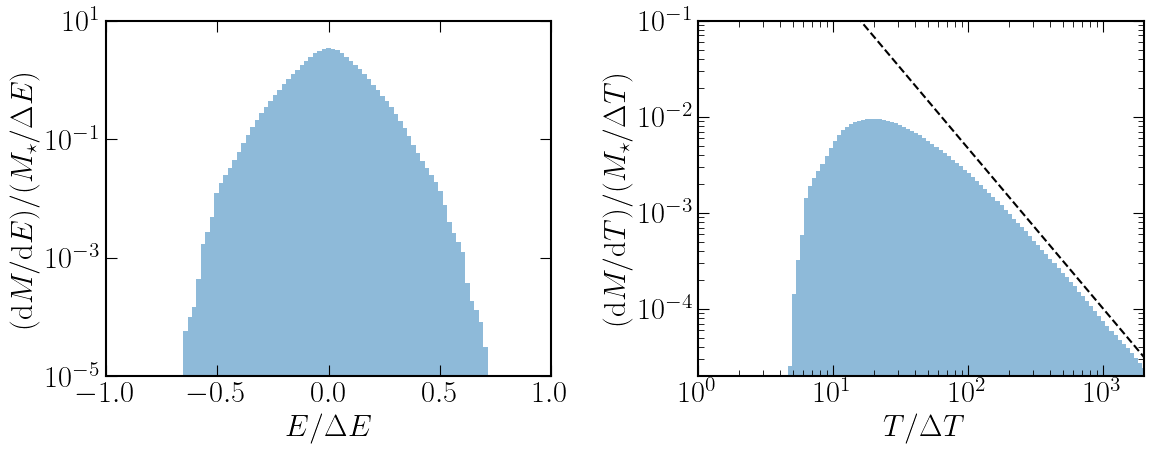

In [ ]:
# dE_rand   = whole_star_sample4['dEnergy_random']      # shape (nr-1, N_Omega)
# dE_unp    = whole_star_sample4['dEnergy_unperturbed']
# dT_rand   = whole_star_sample4['dT_random']
# dT_unp    = whole_star_sample4['dT_unperturbed']
# dMass     = whole_star_sample4['dMass']               # same shape

# # set up figure
# fig, (axE, axT) = plt.subplots(1, 2, figsize=(12,5))

# # histograms in E
# bins_E = np.linspace(-2, 2, 200)
# axE.hist(dE_rand.flatten(),
#          weights=dMass.flatten(),
#          bins=bins_E,
#          density=True,
#          alpha=0.5)
# axE.set_yscale('log')
# axE.set_xlim(-1,1)
# axE.set_ylim(1e-5,10)
# axE.set_xlabel(r'$ E / \Delta E$')
# axE.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}E) / (M_\star / \Delta E)$')

# # histograms in T
# bins_T = np.logspace(0, 6, 200)
# axT.hist(dT_rand.flatten(),
#          weights=dMass.flatten(),
#          bins=bins_T,
#          density=True,
#          alpha=0.5)
# # overplot T^{-5/3} reference
# axT.plot(bins_T, 10*bins_T**(-5/3), 'k--', label=r'$T^{-5/3}$')
# axT.set_xscale('log')
# axT.set_yscale('log')
# axT.set_xlim(1,2000)
# axT.set_ylim(2e-5,0.1)
# axT.set_xlabel(r'$T / \Delta T$')
# axT.set_ylabel(r'$(\mathrm{d}M/\mathrm{d}T) / (M_\star / \Delta T)$')

# plt.tight_layout()
# plt.show()